### OS Analysis

**This notebook analyzes overall survival in patients with advanced non-small cell lung cancer and high PDL1 treated with first-line pembrolizumab or chemotherapy.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/pembro_chemo_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate
11533,F93C9F927CE57,pembro_platinum,2017-12-19
994,F9C30BC9FAC04,pembro_platinum,2018-05-29
3679,F64A1A89FEA1C,pembro_platinum,2017-03-07


In [4]:
treatment_df.shape

(38159, 3)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'pembro').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [7]:
features_df.shape

(1976, 164)

In [8]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [9]:
df.shape

(1976, 167)

In [10]:
df['StartDate'] = pd.to_datetime(df['StartDate'])

In [11]:
df['treatment_year'] = df['StartDate'].dt.year

In [12]:
df = df.query('treatment_year <= 2024')

In [13]:
df.shape

(1808, 168)

In [17]:
df.query('LineName == "pembro_platinum"')

,PatientID,Histology,SmokingStatus,GroupStage_mod,days_diagnosis_to_adv,adv_diagnosis_year,days_adv_to_treatment,days_to_treatment_before_30d,GroupStage_mod_na,before_2020,...,commercial,medicaid,medicare,other_insurance,ses_mod,ses_mod_na,LineName,StartDate,treatment,treatment_year
0,F44AB8A70DB57,Non-squamous cell carcinoma,History of smoking,3.0,0.0,2024,42,0,0,0,...,1,0,0,1,5.0,0,pembro_platinum,2024-05-24,0,2024
1,FF032CFC52D8D,Squamous cell carcinoma,History of smoking,4.0,0.0,2018,36,0,0,1,...,1,0,1,0,3.0,0,pembro_platinum,2018-11-15,0,2018
4,FE724F9396C8C,Non-squamous cell carcinoma,History of smoking,3.0,0.0,2021,35,0,0,0,...,1,1,0,1,3.0,0,pembro_platinum,2021-11-01,0,2021
6,F282B4DDD99E7,Squamous cell carcinoma,History of smoking,4.0,0.0,2023,15,1,0,0,...,1,0,1,0,2.0,0,pembro_platinum,2023-12-06,0,2023
8,FE02DCF8F51F3,Non-squamous cell carcinoma,History of smoking,3.0,91.0,2021,0,1,0,0,...,1,0,1,0,4.0,0,pembro_platinum,2021-08-06,0,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1961,F99F9CE8099FF,Non-squamous cell carcinoma,History of smoking,3.0,0.0,2024,41,0,0,0,...,1,0,1,1,4.0,0,pembro_platinum,2024-05-14,0,2024
1965,F6FCC1B4EF00B,NSCLC histology NOS,History of smoking,4.0,0.0,2019,45,0,0,1,...,1,0,0,0,3.0,1,pembro_platinum,2019-09-16,0,2019
1966,FBF3AC012C48B,Non-squamous cell carcinoma,History of smoking,3.0,0.0,2020,38,0,0,0,...,1,0,1,0,4.0,0,pembro_platinum,2021-01-11,0,2021
1972,F0065C63BD7A0,Squamous cell carcinoma,History of smoking,4.0,0.0,2024,38,0,0,0,...,1,0,1,0,3.0,1,pembro_platinum,2024-04-05,0,2024


## Survival analysis with IPTW

In [14]:
df.treatment.value_counts()

treatment
1    1184
0     624
Name: count, dtype: int64

In [15]:
# Percent censoring
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.354167
1    0.304054
Name: event, dtype: float64

In [16]:
estimator = IPTWSurvivalEstimator()

In [17]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['Histology', 'SmokingStatus'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'hemoglobin', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'days_to_treatment_before_30d'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [18]:
iptw_df = estimator.transform()

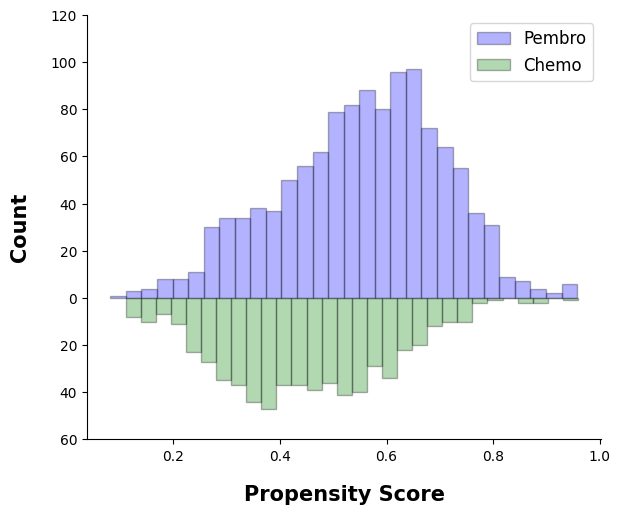

In [19]:
ps_fig = estimator.propensity_score_plot(bins = 30)

ax = ps_fig.axes[0]

ax.set_xlabel('Propensity Score', fontsize = 15)
ax.set_ylabel('Count', fontsize = 15)
ax.set_title('')
ps_fig.set_size_inches(6, 6)

handles, labels = ax.get_legend_handles_labels()
label_map = {'Treatment': 'Pembro', 'Control': 'Chemo'}
ax.legend(handles, [label_map.get(l, l) for l in labels], prop={'size': 12})

ps_fig.savefig('../outputs/ps_plot.pdf', dpi=300, bbox_inches='tight')
ps_fig

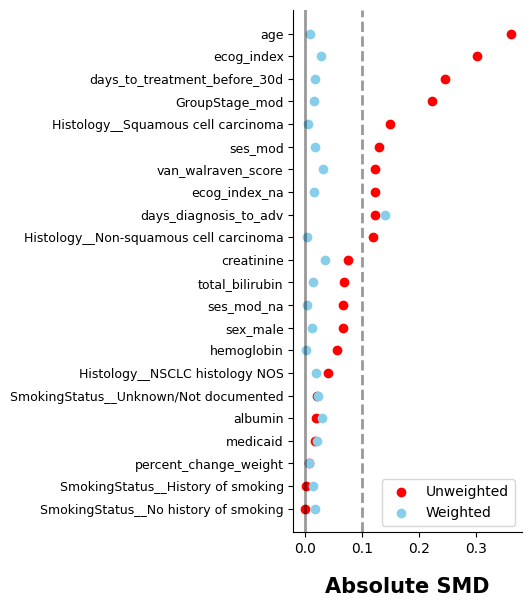

In [20]:
_, smd_fig = estimator.standardized_mean_differences(return_fig = True)

ax = smd_fig.axes[0]

# Resize figure
smd_fig.set_size_inches(4, 6)

# Axis/title font sizes
ax.set_xlabel('Absolute SMD', fontsize=15)
ax.set_title('')

# Reference line styles
for line in ax.lines:
    line.set_alpha(0.4)

ax.tick_params(axis='y', labelsize=9)
ax.legend(prop={'size': 10})
smd_fig

In [21]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42,
                                                               n_jobs = -1)

In [22]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [180, 365, 730, 1095],
                                     rmst_time_points = [180, 365, 730, 1095],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [23]:
# Median results
print('Median survival results')
print(f'Pembrolizumab: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'Chemotherapy: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
Pembrolizumab: (18.5, 15.3, 21.4) months
Chemotherapy: (19.5, 15.5, 24.1) months
Difference: (-0.9, -6.7, 3.4) months


In [24]:
print('RMST results at 6 months')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][180])} days')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][180])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][180])} days')

print('')
print('RMST results at 1 year')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][365])} days')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][365])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][365])} days')

print('')
print('RMST results at 2 years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

RMST results at 6 months
Pembrolizumab: (150.1, 147.0, 153.1) days
Chemotherapy: (152.9, 146.1, 158.2) days
Difference: (-2.8, -8.8, 4.3) days

RMST results at 1 year
Pembrolizumab: (273.0, 265.6, 280.7) days
Chemotherapy: (272.7, 258.8, 286.3) days
Difference: (0.3, -15.3, 15.8) days

RMST results at 2 years
Pembrolizumab: (457.8, 441.9, 474.3) days
Chemotherapy: (461.5, 432.6, 495.3) days
Difference: (-3.7, -38.8, 26.7) days

RMST results at 3 years
Pembrolizumab: (601.0, 576.6, 625.6) days
Chemotherapy: (603.9, 559.6, 656.7) days
Difference: (-2.9, -58.9, 42.3) days


In [25]:
print('Probability of survival at 6 months')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][180])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][180])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][180])}')

print('')
print('Probability of survival at 1 year')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][365])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][365])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][365])}')

print('')
print('Probability of survival at 2 years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

Probability of survival at 6 months
Pembrolizumab: (0.73, 0.704, 0.757)
Chemotherapy: (0.716, 0.674, 0.761)
Difference: (0.013, -0.035, 0.063)

Probability of survival at 1 year
Pembrolizumab: (0.598, 0.569, 0.626)
Chemotherapy: (0.594, 0.549, 0.649)
Difference: (0.003, -0.056, 0.054)

Probability of survival at 2 years
Pembrolizumab: (0.444, 0.414, 0.472)
Chemotherapy: (0.443, 0.396, 0.5)
Difference: (0.001, -0.061, 0.054)

Probability of survival at 3 years
Pembrolizumab: (0.344, 0.313, 0.375)
Chemotherapy: (0.355, 0.309, 0.41)
Difference: (-0.012, -0.074, 0.044)


Text(0.03, 0.05, '$\\Delta \\mathrm{RMST}_{2y}$ = -3.7 days (95% CI, -38.8–26.7)')

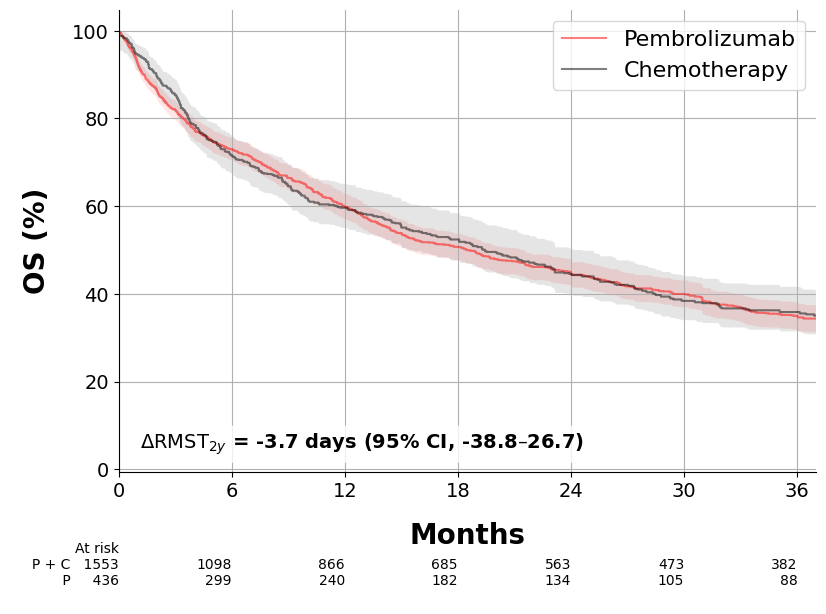

In [26]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# pembro + chemo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Pembrolizumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# pembro estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Chemotherapy')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 37, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 37 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 2 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][730]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['P + C', 'P'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

#plt.savefig('../outputs/os_pembro_chemo.pdf', format='pdf', bbox_inches='tight')